# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Libraries Loaded Successfully")


Libraries Loaded Successfully


# Load dataset

In [3]:
# Load dataset
df = pd.read_csv("synthetic_food_dataset_imbalanced.csv")



# Displaying first 5 rows

In [4]:
df.head(5)

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


# Checking dataset shape

In [5]:
df.shape

(31700, 16)

# Checking column names

In [6]:
print(df.columns.tolist())

['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size', 'Meal_Type', 'Preparation_Method', 'Is_Vegan', 'Is_Gluten_Free', 'Food_Name']


# Dataset information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

# Statistical summary

In [9]:
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


Calories: Mean ≈ 273, but max ≈ 1289 → extreme outliers (likely high‑calorie processed foods).

Protein: Mean ≈ 9.5, but max ≈ 81.7 → unusually high values (possible noise or rare protein‑dense foods).

Sodium: Mean ≈ 335, but max ≈ 2724 → very high sodium levels, likely noisy or extreme processed entries.

Cholesterol: Mean ≈ 26.8, but max ≈ 260 → extreme values compared to median (23).

Fiber: Many entries at 0.0 → could be missing values encoded as zero.

Glycemic Index: Range 0–286, but realistic GI values are usually 0–100 → values above 100 may be noise.

Water Content: Min ≈ 13, Max ≈ 251 → wide spread, but plausible depending on food type.

Dataset Quality Check

Size: The dataset contains 31,325 samples and 16 features, sufficient for robust classification.

Noise/Outliers: Extreme values detected in Calories (1289), Protein (81), Sodium (2724), and Glycemic Index (>100). Fiber has many zeros, possibly missing values.

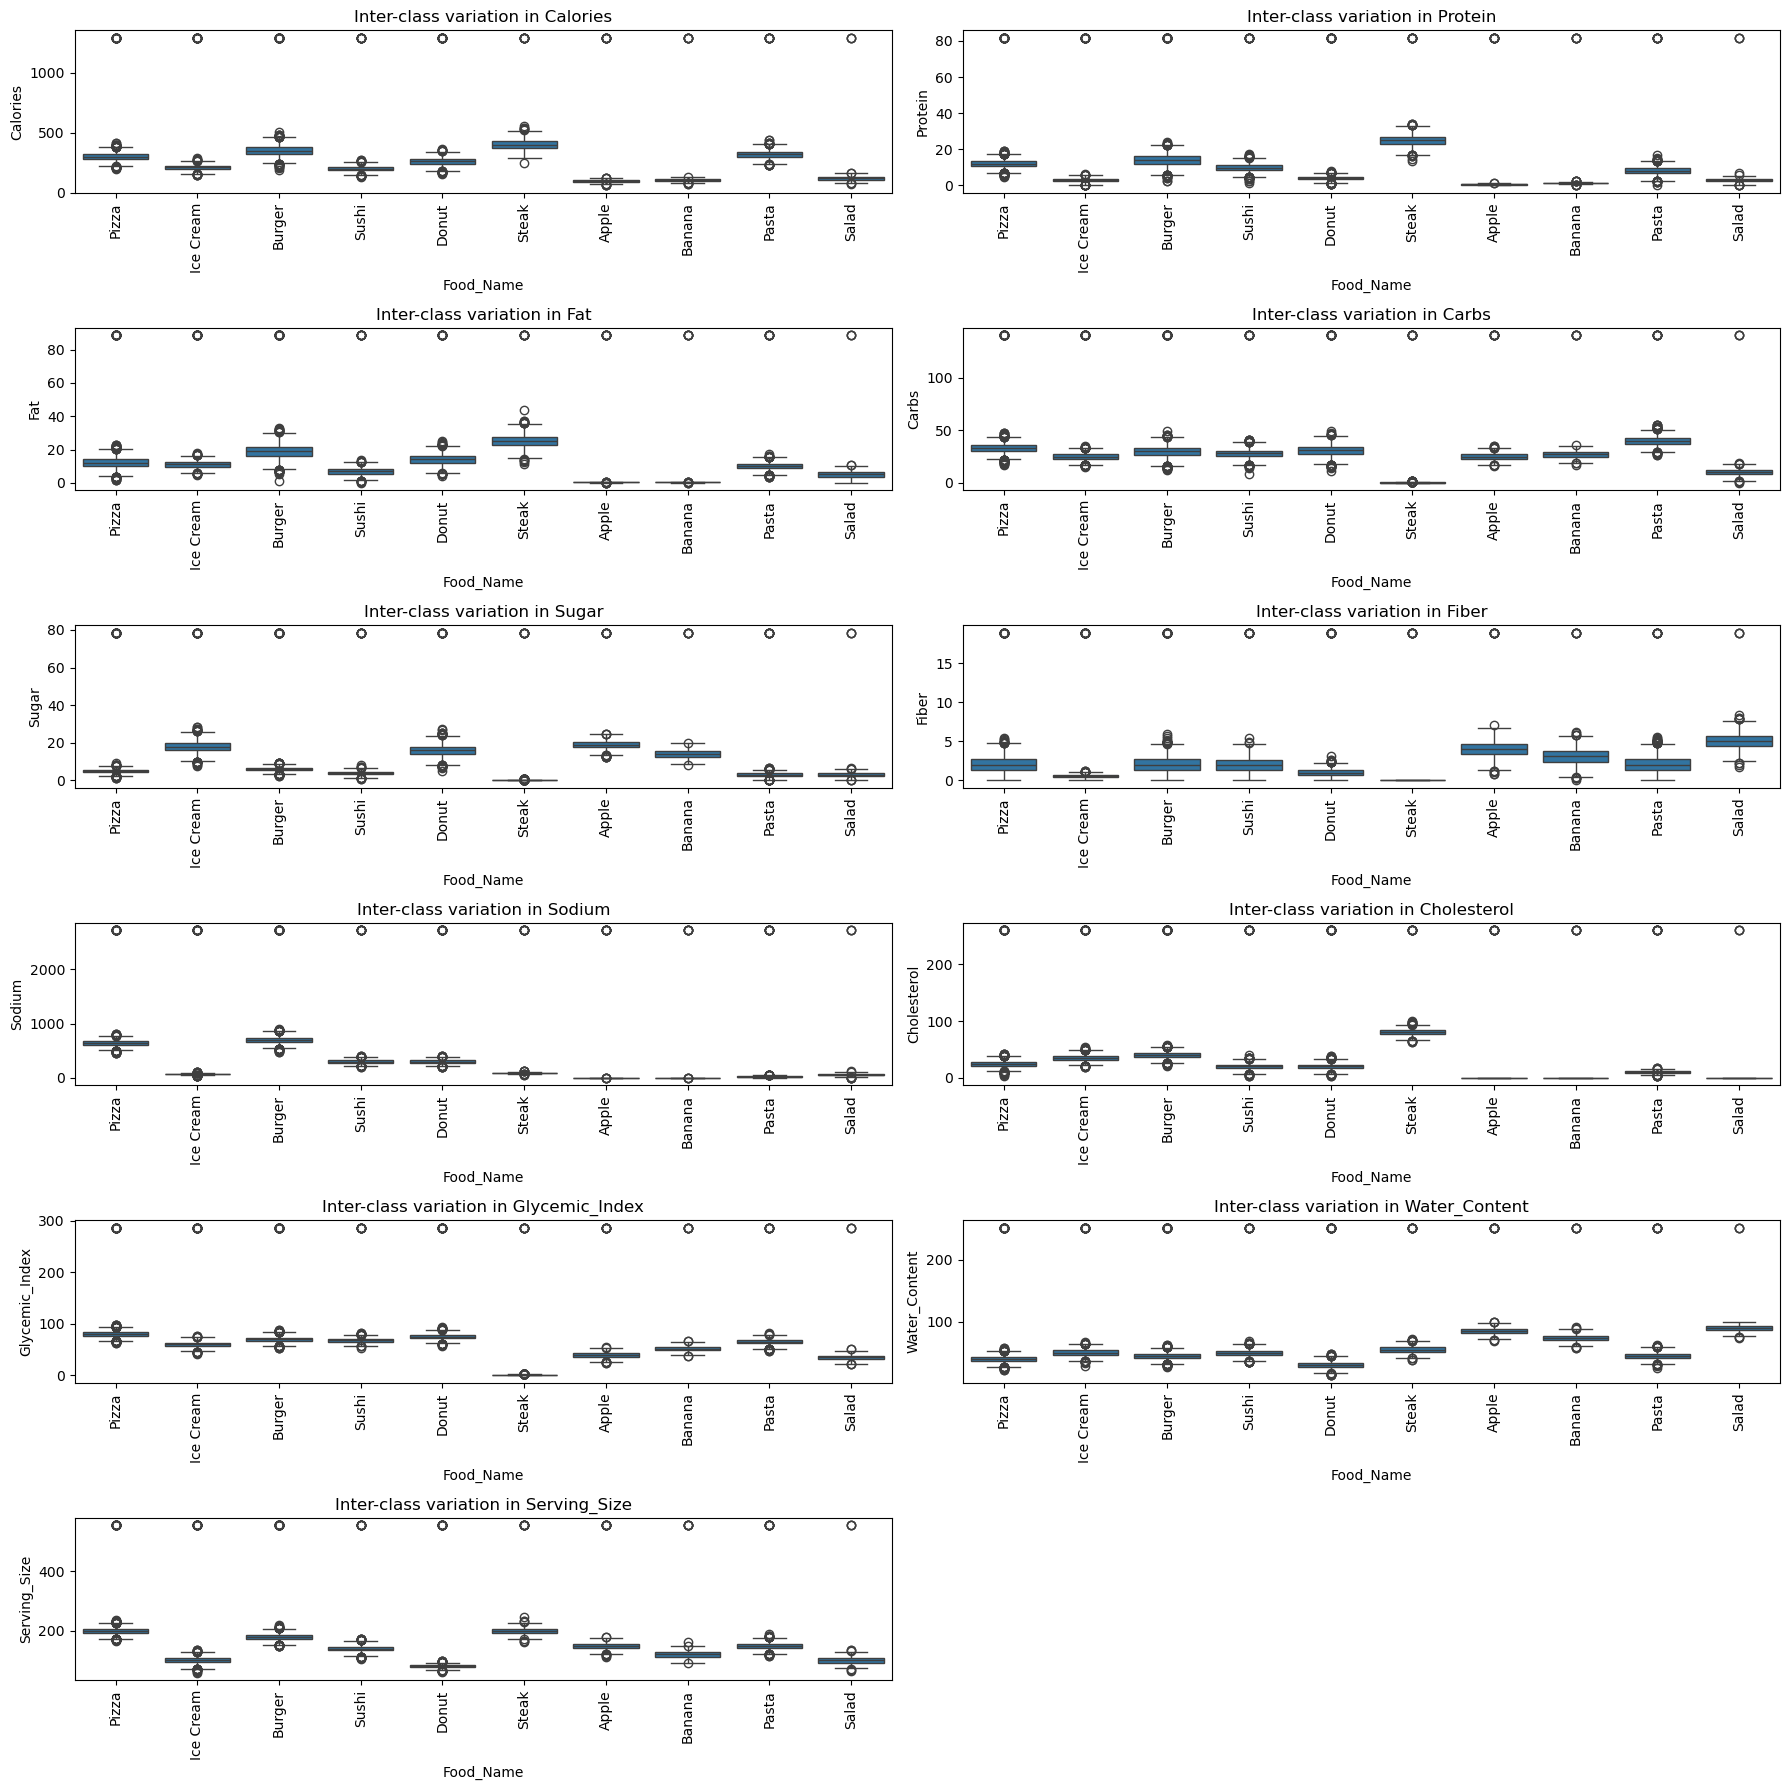

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Boxplots for numerical features ---
num_features = ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 
                'Fiber', 'Sodium', 'Cholesterol', 'Glycemic_Index', 
                'Water_Content', 'Serving_Size']

rows = (len(num_features) + 2 - 1) // 2   # 2 plots per row
fig, axes = plt.subplots(rows, 2, figsize=(18, 3*rows))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.boxplot(x='Food_Name', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f"Inter-class variation in {feature}")
    axes[i].tick_params(axis='x', rotation=90)

# Hide unused subplot slots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




# Identifing the target column

In [22]:
print("Target Column:", "Food_Name")
print("Number of Food Categories:", df["Food_Name"].nunique())

Target Column: Food_Name
Number of Food Categories: 10


# Checking for data imbalance for target column

Food_Name
Pizza        6000
Burger       5000
Donut        4500
Pasta        4000
Sushi        3500
Ice Cream    3000
Steak        2000
Apple        1500
Banana       1200
Salad        1000
Name: count, dtype: int64


<Axes: xlabel='Food_Name'>

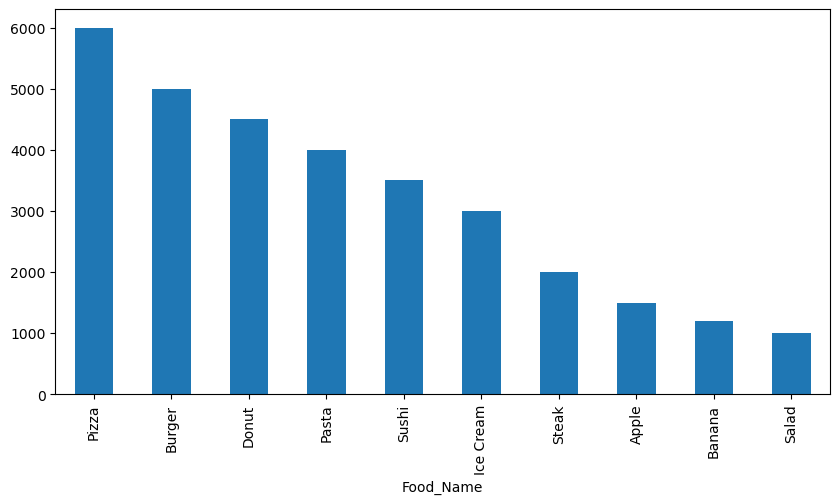

In [20]:
print(df['Food_Name'].value_counts())
df['Food_Name'].value_counts().plot(kind='bar', figsize=(10,5))


Imbalance: Certain food categories dominate (e.g., Pizza, Burger), while others (e.g. banana, Sushi) are underrepresented.

# Checking Imbalance Ratio

In [40]:
counts = df['Food_Name'].value_counts()
imbalance_ratio = counts.max() / counts.min()
print("Imbalance Ratio:", imbalance_ratio)


Imbalance Ratio: 5.957703927492447


# Missing values

In [23]:
df.isna().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

# Duplicate rows

In [24]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 313


# Visualizing the outliers for numerical _columns

In [26]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols


['Calories',
 'Protein',
 'Fat',
 'Carbs',
 'Sugar',
 'Fiber',
 'Sodium',
 'Cholesterol',
 'Glycemic_Index',
 'Water_Content',
 'Serving_Size']

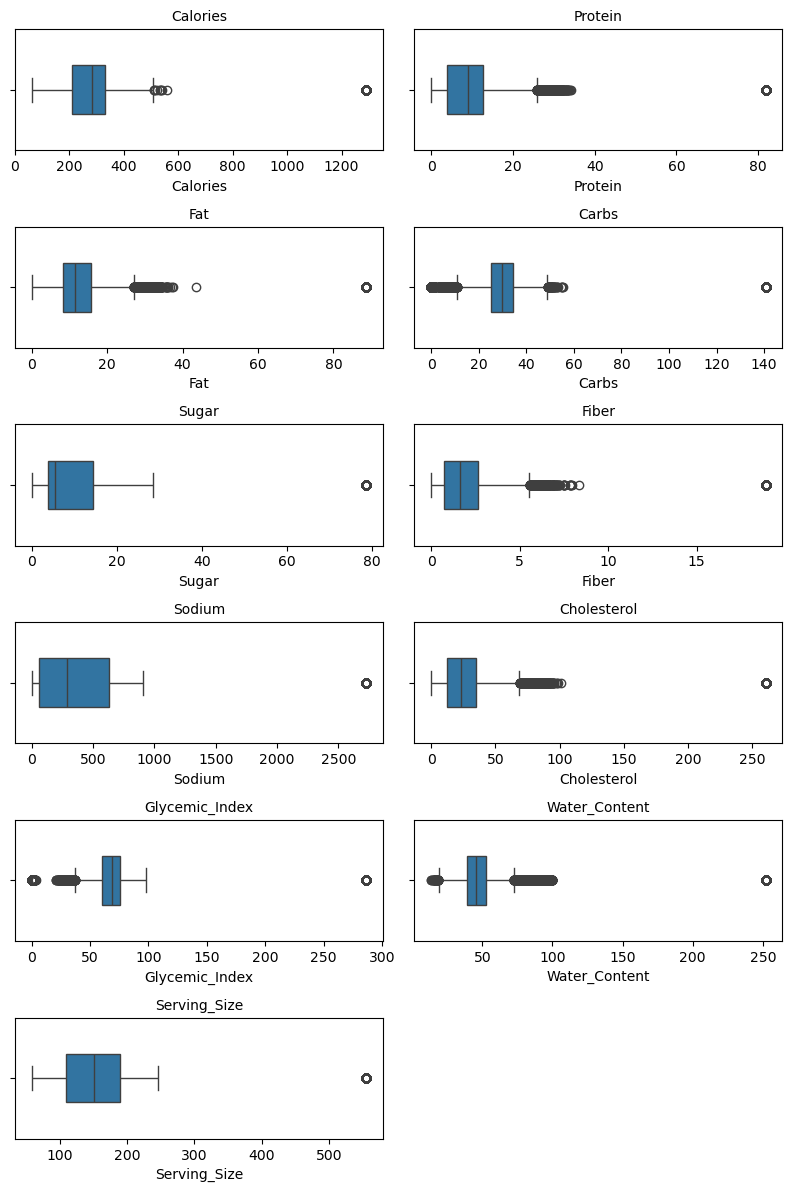

In [27]:
rows = (len(num_cols) + 1) // 2
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(8, 2*rows))  # smaller size

for i, col in enumerate(num_cols):
    r, c = divmod(i, 2)
    sns.boxplot(x=df[col], ax=axes[r][c], width=0.4)  # narrower boxes
    axes[r][c].set_title(f"{col}", fontsize=10)

# Hide empty subplot if odd number of columns
if len(num_cols) % 2 != 0:
    axes[-1][-1].axis("off")

plt.tight_layout(pad=1.0)  # tighter spacing
plt.show()

# Data Preprocessing

# Removing Duplicate Rows

In [28]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (31387, 16)


# Handling Missing Values

In [31]:
from sklearn.impute import SimpleImputer

In [33]:
df.loc[:, num_cols] = imputer.fit_transform(df[num_cols])


# Sum of missing values entries after imputation

In [34]:
df.isna().sum()

Calories              0
Protein               0
Fat                   0
Carbs                 0
Sugar                 0
Fiber                 0
Sodium                0
Cholesterol           0
Glycemic_Index        0
Water_Content         0
Serving_Size          0
Meal_Type             0
Preparation_Method    0
Is_Vegan              0
Is_Gluten_Free        0
Food_Name             0
dtype: int64

# Removing the outliers using IQR method

In [36]:
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df.loc[:, col] = np.clip(df[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)


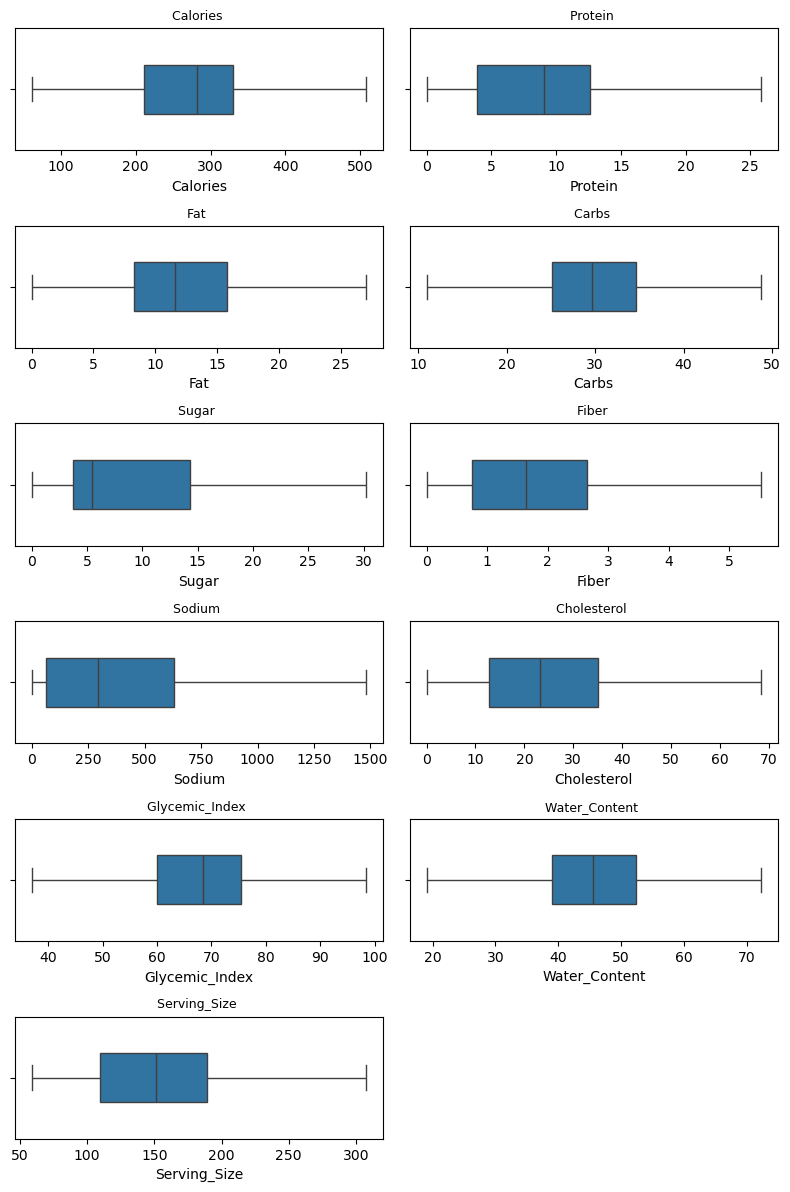

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

rows = (len(num_cols) + 1) // 2   # 2 plots per row
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(8, 2*rows))  # smaller size

for i, col in enumerate(num_cols):
    r, c = divmod(i, 2)
    sns.boxplot(x=df[col], ax=axes[r][c], width=0.4)  # slimmer boxes
    axes[r][c].set_title(f"{col} ", fontsize=9)

# Hide empty subplot if odd number of columns
if len(num_cols) % 2 != 0:
    axes[-1][-1].axis("off")

plt.tight_layout(pad=1.0)
plt.show()

#  Feature Correlation Heatmap

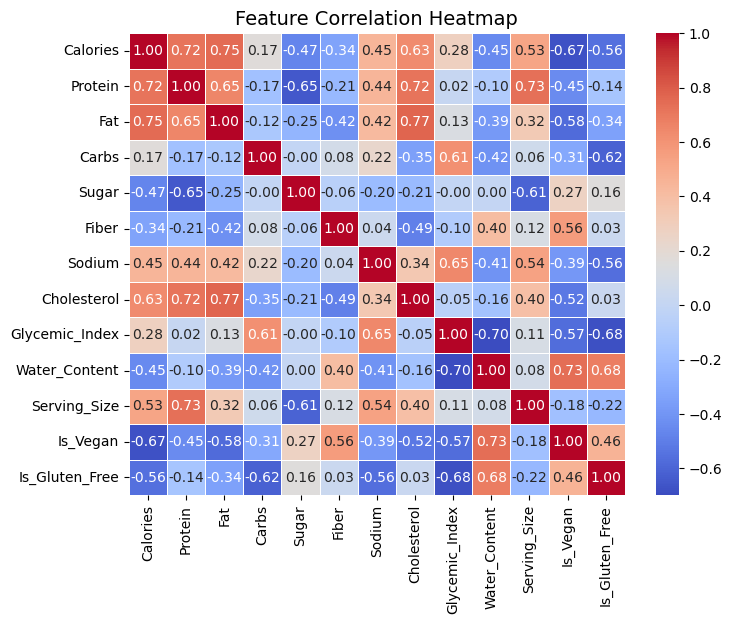

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap with annotations
plt.figure(figsize=(8,6))
sns.heatmap(
    corr, 
    cmap='coolwarm', 
    annot=True,        # show correlation values
    fmt=".2f",         # format to 2 decimal places
    linewidths=0.5     # thin lines between cells
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

In [42]:
df.shape

(31387, 16)

# FEATURE ENGINEERING

In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# --- 1. Label Encoding for categoricals ---
le_meal = LabelEncoder()
le_prep = LabelEncoder()
le_target = LabelEncoder()

# Use .loc to avoid SettingWithCopyWarning
df = df.copy()  # ensure we work on a copy if df was sliced earlier
df.loc[:, 'Meal_Type_enc'] = le_meal.fit_transform(df['Meal_Type'])
df.loc[:, 'Preparation_Method_enc'] = le_prep.fit_transform(df['Preparation_Method'])
df.loc[:, 'Is_Vegan_enc'] = df['Is_Vegan'].astype(int)
df.loc[:, 'Is_Gluten_Free_enc'] = df['Is_Gluten_Free'].astype(int)

# --- 2. Final feature list ---
feature_cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
    'Meal_Type_enc', 'Preparation_Method_enc', 'Is_Vegan_enc', 'Is_Gluten_Free_enc'
]

X = df[feature_cols]
y = df['Food_Name']
y_enc = le_target.fit_transform(y)

print("Features shape:", X.shape)
print("Target classes:", len(le_target.classes_))

Features shape: (31387, 15)
Target classes: 10


In [49]:
print("Target classes:", le_target.classes_[:10])

Target classes: ['Apple' 'Banana' 'Burger' 'Donut' 'Ice Cream' 'Pasta' 'Pizza' 'Salad'
 'Steak' 'Sushi']


In [55]:
X.shape


(31387, 15)

In [56]:
y.shape

(31387,)

In [57]:
X.head()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type_enc,Preparation_Method_enc,Is_Vegan_enc,Is_Gluten_Free_enc
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,1,1,0,0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,3,3,0,1
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,3,3,0,0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,2,1,0,1
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,3,0,0,0


In [58]:
y.head(10)

0        Pizza
1    Ice Cream
2       Burger
3        Sushi
4        Donut
5       Burger
6    Ice Cream
7    Ice Cream
8        Steak
9       Burger
Name: Food_Name, dtype: object

In [62]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, classification_report,
    precision_recall_fscore_support
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

In [63]:
## 11. TRAIN/TEST SPLIT + SCALING + PCA
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X.shape[1])
print("PCA components (95% variance):", X_train_pca.shape[1])
print("Train shape:", X_train_pca.shape)
print("Test shape:", X_test_pca.shape)

Original features: 15
PCA components (95% variance): 9
Train shape: (25109, 9)
Test shape: (6278, 9)


In [64]:
## 12. MODEL TRAINING & COMPARISON
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42, probability=True),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
model_objects = {}
best_model = None
best_name = ""
best_acc = 0.0

print("Training 7 models...\n")
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    model_objects[name] = model
    
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro'
    )
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision_macro': precision_macro,
        'Recall_macro': recall_macro,
        'F1_macro': f1_macro,
        'CV_5fold': cv_scores.mean()
    })
    
    print(f"{name}: {acc:.3f} accuracy, {cv_scores.mean():.3f} CV")
    
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(f"\n🏆 BEST MODEL: {best_name} ({best_acc:.3f})")
results_df

Training 7 models...

Logistic Regression: 0.990 accuracy, 0.988 CV
Decision Tree: 0.980 accuracy, 0.977 CV
Random Forest: 0.984 accuracy, 0.983 CV
KNN: 0.987 accuracy, 0.986 CV
SVM: 0.990 accuracy, 0.989 CV
XGBoost: 0.988 accuracy, 0.986 CV
Gradient Boosting: 0.987 accuracy, 0.986 CV

🏆 BEST MODEL: Logistic Regression (0.990)


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,CV_5fold
0,Logistic Regression,0.990443,0.990807,0.990876,0.990830,0.987614
4,SVM,0.990443,0.992142,0.991800,0.991959,0.989406
5,XGBoost,0.987576,0.989040,0.988936,0.988979,0.986260
3,KNN,0.986779,0.988657,0.988034,0.988324,0.985901
6,Gradient Boosting,0.986779,0.987385,0.987308,0.987339,0.985941
2,Random Forest,0.984071,0.984980,0.984930,0.984928,0.983392
1,Decision Tree,0.979771,0.978434,0.978315,0.978349,0.976741
